## Animations of distant retrograde orbits

define figure for which to do this

- read final orbit files
- finish all movies, cosmetics for HCI animation (e.g. use shade for different spacecraft)
- dro movie with 9 at 0.86 au (SHIELD configuration)
- movie in HCI with more spacecraft - finish
- with ffmpeg
- use black background partly


### load planetary orbits
get planetary orbits from spiceypy with files    
load de442.bsp from https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/    
other files already available in folder: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/    
saved in folder /kernels



In [1]:
import time
import os
import requests
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
from matplotlib.patches import Rectangle

import pickle
import spiceypy
import pandas as pd
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy import stats
from scipy.signal import argrelextrema
import multiprocessing as mp

import astropy.units as u
from astropy import constants as const

au=const.au.value*1e-3
M_sun = const.M_sun.value  # Sun mass
M_earth = const.M_earth.value   # Earth mass
G=const.G.value*1e-9 # use km
# Sun-Earth system parameters mu: mass parameter (m2/(m1+m2))
mu = M_earth/(M_sun+M_earth)  # Earth mass / (Sun + Earth mass)

# Calculate system parameters
M_total = M_sun + M_earth
omega = np.sqrt(G * M_total / au**3)  # Angular velocity of rotating frame (rad/s) from keplers laws?
T=2*np.pi/omega/86400 #year in decimal days

print('Au in km:',au) # in km
print('M sun',M_sun)
print('M earth',M_earth)
print('G:',G)

print(f"System Parameters:")
print(f"  Mass parameter μ = {mu:.6e}")
print(f"  Earth-Sun distance au = {au:.6e} km")
print(f"  Angular velocity ω = {omega:.6e} rad/s")
print(f"  Orbital period = {2*np.pi/omega/86400:.2f} days\n")

kernels_path='kernels'

#make sure to convert the current notebook to a script if you want to run it on a server
os.system('jupyter nbconvert --to script animations.ipynb')   


Au in km: 149597870.70000002
M sun 1.988409870698051e+30
M earth 5.972167867791379e+24
G: 6.6743e-20
System Parameters:
  Mass parameter μ = 3.003480e-06
  Earth-Sun distance au = 1.495979e+08 km
  Angular velocity ω = 1.990987e-07 rad/s
  Orbital period = 365.26 days



[NbConvertApp] Converting notebook animations.ipynb to script
[NbConvertApp] Writing 23503 bytes to animations.py


0

File already exists at kernels/de442.bsp
['de442.bsp', 'heliospheric_v004u.tf', '.DS_Store', 'naif0012.tls', 'pck00010.tpc']
kernels


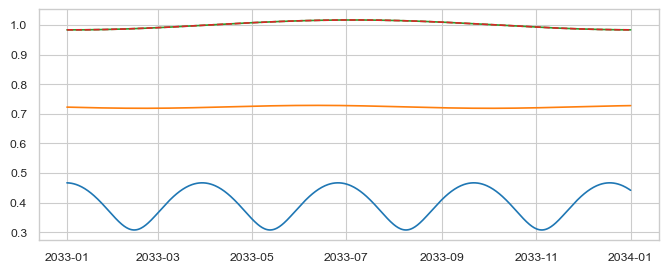

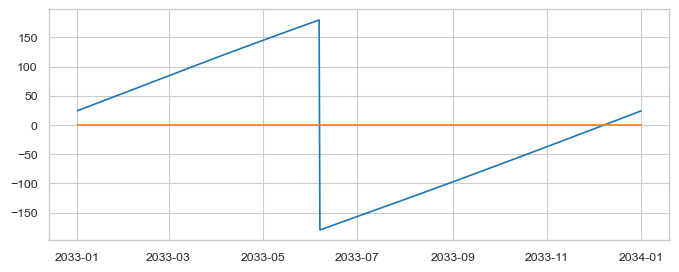

In [2]:
#check if de442.bsp is available, otherwise download

def download_if_not_exist(url, filepath):
    if os.path.exists(filepath):
        print(f"File already exists at {filepath}")
        return filepath
    
    # Create directory if needed
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    
    # Download
    response = requests.get(url)
    response.raise_for_status()
    
    with open(filepath, 'wb') as f:
        f.write(response.content)
    
    print(f"Downloaded to {filepath}")
    return filepath


filepath='kernels/de442.bsp'
url='https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de442.bsp'

download_if_not_exist(url,filepath)

#use two arbitray years for the planets
start=datetime.datetime(2033,1,1)
end=datetime.datetime(2034,1,1)

times = [] 
dt=12 #time resolution for planets is 1 day
# Generate datetimes with increments of dt hours until the end date
current = start
while current <= end:
    times.append(current)
    current += datetime.timedelta(hours=dt)
    

def cart2sphere_rad(x,y,z):
    
    r = np.sqrt(x**2+ y**2 + z**2) / au
    theta = np.arctan2(z,np.sqrt(x**2+ y**2)) * 360 / 2 / np.pi
    phi = np.arctan2(y,x) * 360 / 2 / np.pi    
    
    theta=np.deg2rad(theta)
    phi=np.deg2rad(phi)
    
    return (r, theta, phi)

def generic_furnish(kernels_path):
    generic_path = kernels_path
    generic_kernels = os.listdir(generic_path)
    print(generic_kernels)    
    #spiceypy.furnsh(os.path.join(generic_path, 'de442.bsp'))
        
    for kernel in generic_kernels:
        spiceypy.furnsh(os.path.join(generic_path, kernel))
        
def get_planet_pos(t,kernels_path, planet):
    if spiceypy.ktotal('ALL') < 1:
        generic_furnish(kernels_path)
    pos = spiceypy.spkpos(planet, spiceypy.datetime2et(t), "HEEQ", "NONE", "SUN")[0]
    r, lat, lon = cart2sphere_rad(pos[0],pos[1],pos[2])
    position = t, pos[0], pos[1], pos[2], r, lat, lon
    return position


def get_planet_positions(time_series,kernels_path,planet):
    positions = []
    for t in time_series:
        position = get_planet_pos(t,kernels_path, planet)
        positions.append(position)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    return df_positions



def get_planet_pos_hci(t,kernels_path, planet):
    if spiceypy.ktotal('ALL') < 1:
        generic_furnish(kernels_path)
    pos = spiceypy.spkpos(planet, spiceypy.datetime2et(t), "HCI", "NONE", "SUN")[0]
    r, lat, lon = cart2sphere_rad(pos[0],pos[1],pos[2])
    position = t, pos[0], pos[1], pos[2], r, lat, lon
    return position


def get_planet_positions_hci(time_series,kernels_path,planet):
    positions = []
    for t in time_series:
        position = get_planet_pos_hci(t,kernels_path, planet)
        positions.append(position)
    df_positions = pd.DataFrame(positions, columns=['time', 'x', 'y', 'z', 'r', 'lat', 'lon'])
    return df_positions





# make Earth Mercury and Venus positions
generic_furnish(kernels_path)    
print(kernels_path)
mercury=get_planet_positions(times,kernels_path, 'MERCURY_BARYCENTER')
venus=get_planet_positions(times,kernels_path, 'VENUS_BARYCENTER')
earth=get_planet_positions(times,kernels_path, 'EARTH_BARYCENTER')

earth_hci=get_planet_positions_hci(times,kernels_path, 'EARTH_BARYCENTER')



#to matplotlib datenumber
#mercury.time=mdates.date2num(mercury.time)
#venus.time=mdates.date2num(venus.time)
#earth.time=mdates.date2num(earth.time)


sns.set_style('whitegrid')
sns.set_context('paper')   
# Create the plot
fig, ax = plt.subplots(figsize=(8, 3),dpi=100)
plt.plot(mercury.time,mercury.r,'-')
plt.plot(venus.time,venus.r,'-')
plt.plot(earth.time,earth.r,'-')
plt.plot(earth_hci.time,earth_hci.r,'--')

fig, ax = plt.subplots(figsize=(8, 3),dpi=100)
plt.plot(earth_hci.time,np.rad2deg(earth_hci.lon))
plt.plot(earth.time,np.rad2deg(earth.lon))






### read orbit files

In [3]:
#START HERE *********************


### reading the pickle file for the 0.86 au orbit
filename='orbit_files/dro06__0_86au.p'
with open(filename,'rb') as f:
    dro = pickle.load(f)

filename='orbit_files/dro09__0_92au.p'
with open(filename,'rb') as f:
    dro2 = pickle.load(f)

In [1]:
sns.set_style('darkgrid')
sns.set_context('talk')    
    
############## number of SHIELD spacecraft #########
nr_sc=9
#################################################


t_all=365*1*24 # all time datapoints ****** need to set global time resolution better
interval=int(np.round(t_all/nr_sc)) #to nearest day
#indices of shield spacecraft equidistant in time over 1 year
shield_i=np.arange(0,t_all,interval)

print('Number of SHIELD Spacecraft:',nr_sc)
print('Interval in days:',interval/24)
print('longitudes:',np.round(np.rad2deg(dro_lon3[shield_i])))


def make_frame(i):

    fig, ax = plt.subplots(1,figsize=(10, 8),subplot_kw={'projection': 'polar'},dpi=200)    

    fsize=15
    symsize_planet=10

    ax.text(0,0,'Sun', color='black', ha='center',fontsize=fsize-5,verticalalignment='top')
    #ax.text(0,1.2,'Earth', color='mediumseagreen', ha='center',fontsize=fsize-5,verticalalignment='center')

    # Sun
    ax.scatter(0,0,s=100,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)

    ax.scatter(earth.lon, earth.r, s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3,marker=None, label='Earth')  
    ax.plot(venus.lon, venus.r, c='gold', alpha=1,lw=1,zorder=3, marker=None, label='Venus')  
    #ax.plot(mercury.lon, mercury.r, c='grey', alpha=0.5,lw=1,zorder=3, marker=None, label='Mercury')  

    ax.plot(dro_lon1, dro_r1,c='black', alpha=0.8,lw=1, markersize=1, label='DRO 0.95 au')
    ax.plot(dro_lon2, dro_r2,c='red', alpha=0.8,lw=1, markersize=1, label='DRO 0.90 au')
    #ax.plot(dro_lon3, dro_r3,c='blue', alpha=0.8,lw=1, markersize=1, label='DRO 0.85 au')
    ax.plot(dro_lons1, dro_rs1,c='purple', alpha=0.8,lw=1, markersize=1, label='DRO SHIELD 0.86 au')
    ax.plot(dro_lon4, dro_r4,c='green', alpha=0.8,lw=1, markersize=1, label='DRO 0.80 au')
    ax.plot(dro_lon5, dro_r5,c='orange', alpha=0.8,lw=1, markersize=1, label='DRO 0.75 au')
    

    #advance by factor frames

    ax.scatter(dro_lon1[shield_i+i*factor], dro_r1[shield_i+i*factor],c='black', marker='o',s=5)
    ax.scatter(dro_lon2[shield_i+i*factor], dro_r2[shield_i+i*factor],c='red', marker='o',s=5)
    #ax.scatter(dro_lon3[shield_i+i*factor], dro_r3[shield_i+i*factor],c='blue', marker='o',s=5)
    ax.scatter(dro_lons1[shield_i+i*factor], dro_rs1[shield_i+i*factor],c='purple', marker='o',s=5)
    
    ax.scatter(dro_lon4[shield_i+i*factor], dro_r4[shield_i+i*factor],c='green', marker='o',s=5)
    ax.scatter(dro_lon5[shield_i+i*factor], dro_r5[shield_i+i*factor],c='orange', marker='o',s=5)
    

    #1 au circle
    ax.plot(np.deg2rad(np.arange(0,360)),np.zeros(360)+1,lw=1,alpha=0.8,linestyle='--',c='black', marker=None)

    ax.plot(np.zeros(11),np.arange(0,1.1,0.1),c='k',lw=1,alpha=0.8,linestyle='--')



    degrees = np.arange(-60,60,10)
    ax.set_xticks(np.radians(degrees))
    ax.set_xticklabels([f'{d}°' for d in degrees], fontsize=15)

    ax.set_rgrids(np.arange(0.2,1.5,0.1),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2','1.3'),angle=50, fontsize=10)


    ax.set_theta_zero_location('E')
    ax.set_thetamin(60)      # Start angle in degrees
    ax.set_thetamax(-60)
    ##plt.title('Planet and simulated DRO positions 2028 Jan 1 - 2030 Jan 1')
    ax.set_ylim(0, 1.3) 

    #ax.set_rgrids((0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2'), angle=0, fontsize=5, alpha=0.1)
    ax.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=10)
    plt.tight_layout()
    

    plt.figtext(0.2,0.8,f' {nr_sc} DRO spacecraft', color='black', ha='left',fontsize=fsize-4, style='italic')
    plt.figtext(0.2,0.75,f'time:   {np.round(i*factor/24,2)} days', color='black', ha='left',fontsize=fsize-4, style='italic')


    plt.figtext(0.05,0.01,'Austrian Space Weather Office   GeoSphere Austria', color='black', ha='left',fontsize=fsize-4, style='italic')
    plt.figtext(0.99,0.01,'helioforecast.space', color='black', ha='right',fontsize=fsize-4, style='italic')

    plt.savefig(f'results/frames/dro{i:04d}.jpg', dpi=200,bbox_inches='tight')
    #plt.close()
    
    return 0

factor=12
make_frame(500)

NameError: name 'sns' is not defined

In [2]:
#make_animation=False
make_animation=False


if make_animation:

    print()
    print('make animation')
    print()
        
    ffmpeg_path=''
    outputdirectory = 'results/frames'
    animdirectory   = 'results/'
    
    factor=12
    i_all=int(365*24/factor) #365*24 for all frames for 1 year, 1 hour resolution, divided by factor
    counter=[i for i in range(i_all)]
    
    print('number of frames',i_all)
    
    used=8
    print('Using multiprocessing, nr of cores',mp.cpu_count(), \
          'with nr of processes used: ',used)
    
    #define pool using fork and number of processes
    pool=mp.get_context('fork').Pool(processes=used)
    # Map the worker function onto the parameters    
    t0 = time.time()
    pool.map(make_frame, counter) #or use apply_async?,imap
    pool.close()
    pool.join()     
    t1 = time.time()
    
    
    print('time in sec: ',np.round((t1-t0),1))
    print('plots done, frames saved in ',outputdirectory)


    movie_filename=f'dro_{nr_sc}'
    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.mp4 -y -loglevel quiet')    
    print('movie done, saved in ',animdirectory)
    
    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.gif -y -loglevel quiet')    




## try in HCI with only rotation

In [3]:
sns.set_style('darkgrid')
sns.set_context('talk')    
    
############## number of SHIELD spacecraft #########
nr_sc=9
#################################################


t_all=365*1*24 # all time datapoints ****** need to set global time resolution better
interval=int(np.round(t_all/nr_sc)) #to nearest day
#indices of shield spacecraft equidistant in time over 1 year
shield_i=np.arange(0,t_all,interval)

print('Number of SHIELD Spacecraft:',nr_sc)
print('Interval in days:',interval/24)
print('longitudes:',np.rad2deg(dro_lon3[shield_i]))




def make_frame_hci(i):


    fig, ax = plt.subplots(1,figsize=(10, 8),subplot_kw={'projection': 'polar'},dpi=200)    

    fsize=15
    symsize_planet=60
    spacecraft_size=10

    #advance for rotation
    #advance by 0.5 days in longitude or 1/720 degree per time step
    lonstep=np.deg2rad(360/720)*i


    ax.text(0,0,'Sun', color='black', ha='center',fontsize=fsize-5,verticalalignment='top')
    #ax.text(0,1.2,'Earth', color='mediumseagreen', ha='center',fontsize=fsize-5,verticalalignment='center')

    # Sun
    ax.scatter(0,0,s=200,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)

    #ax.scatter(earth.lon+lonstep, earth.r, s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3,marker=None, label='Earth')  
    ax.scatter(venus.lon[i], venus.r[i], c='gold', alpha=1,lw=1,zorder=3, marker=None, label='Venus')  
    ax.scatter(mercury.lon[i], mercury.r[i], c='grey', alpha=1.0,lw=1,zorder=3, marker=None, label='Mercury')  
    ax.scatter(earth.lon[i]+lonstep, earth.r[i], s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3,marker=None, label='Earth')      
    
    #DRO orbit as line
    #ax.plot(dro_lons1+lonstep, dro_rs1,c='purple', alpha=0.8,lw=1, markersize=1, label='DRO SHIELD 0.86 au')
    
    #spacecraft as points , factor frames is time resolution in hours?
    ax.scatter(dro_lons1[shield_i+i*factor]+lonstep, dro_rs1[shield_i+i*factor],c='purple', marker='o',s=5)


    #1 au circle
    ax.plot(np.deg2rad(np.arange(0,360)),np.zeros(360)+1,lw=1,alpha=0.5,linestyle='--',c='black', marker=None)
    ax.plot(np.zeros(11),np.arange(0,1.1,0.1),c='k',lw=1,alpha=0.5,linestyle='--')

    degrees = np.arange(0,360,20)
    ax.set_xticks(np.radians(degrees))
    ax.set_xticklabels([f'{d}°' for d in degrees], fontsize=15)

    ax.set_rgrids(np.arange(0.1,1.5,0.1),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2','1.3','1.4'),angle=50, fontsize=10)

    ax.set_theta_zero_location('E')
    #ax.set_thetamin(60)      # Start angle in degrees
    #ax.set_thetamax(-60)
    ##plt.title('Planet and simulated DRO positions 2028 Jan 1 - 2030 Jan 1')
    ax.set_ylim(0, 1.35) 

    #ax.set_rgrids((0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2'), angle=0, fontsize=5, alpha=0.1)
    #ax.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=10)
    plt.tight_layout()
    

    plt.figtext(0.1,0.9,f'9 DRO spacecraft', color='black', ha='left',fontsize=fsize-4, style='italic')
    plt.figtext(0.1,0.85,f'time:   {np.round(i*factor/24,2)} days', color='black', ha='left',fontsize=fsize-4, style='italic')

    plt.figtext(0.05,0.01,'Austrian Space Weather Office   GeoSphere Austria', color='black', ha='left',fontsize=fsize-4, style='italic')
    plt.figtext(0.99,0.01,'helioforecast.space', color='black', ha='right',fontsize=fsize-4, style='italic')

    plt.savefig(f'results/frames_hci/dro{i:04d}.jpg', dpi=200,bbox_inches='tight')
    plt.close()
    #plt.show()
    

factor=12
make_frame_hci(200)

NameError: name 'sns' is not defined

In [4]:
make_animation=False
#make_animation=True


if make_animation:

    print()
    print('make animation')
    print()
        
    ffmpeg_path=''
    outputdirectory = 'results/frames_hci'
    animdirectory   = 'results/'
    
    factor=12
    i_all=int(365*24/factor) #365*24 for all frames for 1 year, 1 hour resolution, divided by factor
    counter=[i for i in range(i_all)]
    
    print('number of frames',i_all)
    
    used=8
    print('Using multiprocessing, nr of cores',mp.cpu_count(), \
          'with nr of processes used: ',used)
    
    #define pool using fork and number of processes
    pool=mp.get_context('fork').Pool(processes=used)
    # Map the worker function onto the parameters    
    t0 = time.time()
    pool.map(make_frame_hci, counter) #or use apply_async?,imap
    pool.close()
    pool.join()     
    t1 = time.time()
   
    print('time in sec: ',np.round((t1-t0),1))
    print('plots done, frames saved in ',outputdirectory)

    movie_filename=f'dro_{nr_sc}_hci'
    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.mp4 -y -loglevel quiet')    
    print('movie done, saved in ',animdirectory)
    
    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.gif -y -loglevel quiet')    



### make one movie with HCI coordinates for visualizing how DROs rotate around Earth

new version: just add longitude to all dro spacecraft


In [15]:
#use dro_shield at 0.86 au
#generate Earth in HCI like above but in hours, then add the dros

start=datetime.datetime(2033,1,1)
end=datetime.datetime(2034,12,31,23)

times = [] 
dt=1 #time resolution is 1 hour
# Generate datetimes with increments of dt hours until the end date
current = start
while current <= end:
    times.append(current)
    current += datetime.timedelta(hours=dt)
    
earth_hci=get_planet_positions_hci(times,kernels_path, 'EARTH_BARYCENTER')




############################## ********************
#version 1
#this is one spacecraft, all the others are phase shifted, i.e. the orbit is not the same in this frame
dro3_x_hci=(dro3.x-1.0)+earth_hci.x/au
dro3_y_hci=dro3.y+earth_hci.y/au
dro3_r_hci= np.sqrt(dro3_x_hci**2 + dro3_y_hci**2)
dro3_lon_hci = np.arctan2(dro3_y_hci, dro3_x_hci)



#version 2 - add here a longitude with each time step

#shield orbit is dro_lons1, dro_rs1, xs1, ys1

#ax.scatter(dro_lons1[shield_i], dro_rs1[shield_i],c='blue', marker='o',s=5)



############################## ********************


#x_rot = x·cos(ωt) + y·sin(ωt)
#y_rot = -x·sin(ωt) + y·cos(ωt)

#make time in hour resolution for 2 years
#mtime= np.arange('2033-01-01', '2035-01-01', dtype='datetime64[h]')
#mtime_num=(mdates.date2num(mtime)-mdates.date2num(mtime)[0])*24 #convert to hours
#print(mtime_num)
#Earth is at 0,0, then move Earth and add dro3.x dro3.y to this
#earth_x_hci=
#earth_y_hci=
# omega is available in rad/s - rad per hour = *3600
#omega_hour=omega*3600

#dro3_x_hci=dro3.x*np.cos(omega_hour*mtime_num)+dro3.y*np.sin(omega_hour*mtime_num)
#dro3_y_hci=-dro3.x*np.sin(omega_hour*mtime_num)+dro3.y*np.cos(omega_hour*mtime_num)



Number of SHIELD Spacecraft: 1
Interval in days: 365.0
longitudes: [0.]


0

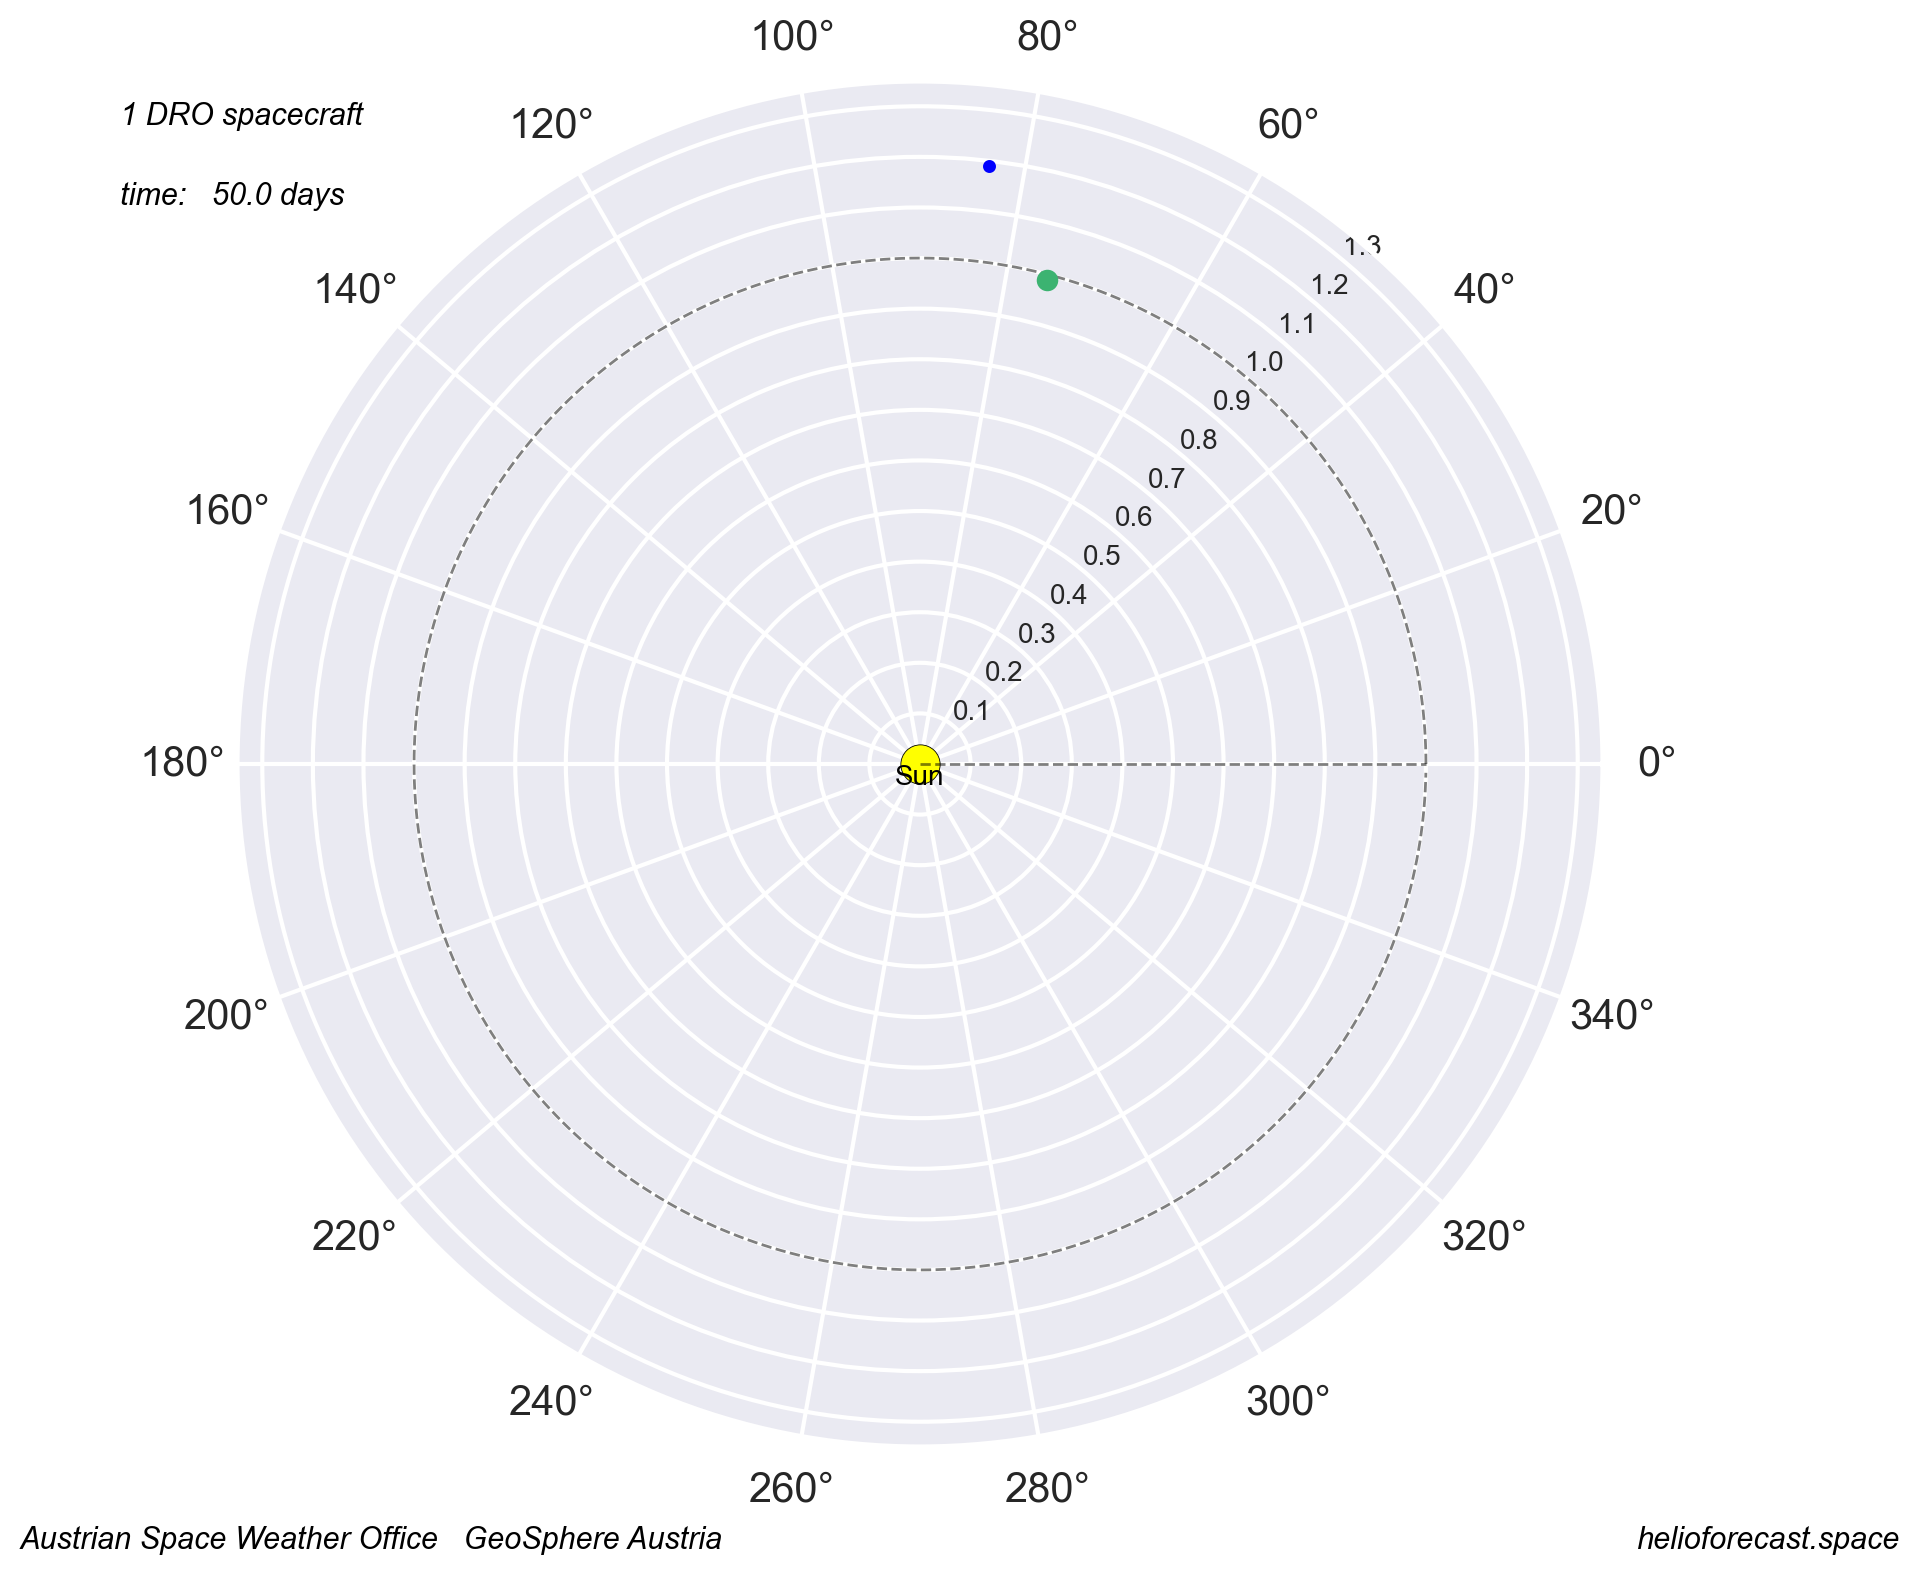

In [16]:
sns.set_style('darkgrid')
sns.set_context('talk')    
    
############## number of SHIELD spacecraft #########
nr_sc=1
#################################################


t_all=365*1*24 # all time datapoints ****** need to set global time resolution better
interval=int(np.round(t_all/nr_sc)) #to nearest day
#indices of shield spacecraft equidistant in time over 1 year
shield_i=np.arange(0,t_all,interval)
#shield_i=0

print('Number of SHIELD Spacecraft:',nr_sc)
print('Interval in days:',interval/24)
print('longitudes:',np.round(np.rad2deg(dro_lon3[shield_i])))


def make_frame_hci(i):


    fig, ax = plt.subplots(1,figsize=(10, 8),subplot_kw={'projection': 'polar'},dpi=200)    

    fsize=15
    symsize_planet=60
    spacecraft_size=10

    ax.text(0,0,'Sun', color='black', ha='center',fontsize=fsize-5,verticalalignment='top')
    #ax.text(0,1.2,'Earth', color='mediumseagreen', ha='center',fontsize=fsize-5,verticalalignment='center')

    # Sun
    ax.scatter(0,0,s=200,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)
    #Earth
    ax.scatter(earth_hci.lon[shield_i+i*factor], earth_hci.r[shield_i+i*factor], s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3,marker=None, label='Earth')  

    #DRO spacecraft
    #ax.scatter(dro_lons1[shield_i+i*factor], dro_rs1[shield_i+i*factor],c='purple', marker='o',s=5)

    
    #DRO spacecraft
    ax.scatter(dro3_lon_hci[shield_i+i*factor], dro3_r_hci[shield_i+i*factor],c='blue', marker='o',s=spacecraft_size)
    
    #this is the orbit in HCI
    #ax.plot(dro3_lon_hci, dro3_r_hci,c='blue')

    #1 au circle
    ax.plot(np.deg2rad(np.arange(0,360)),np.zeros(360)+1,lw=1,alpha=0.5,linestyle='--',c='black', marker=None)
    ax.plot(np.zeros(11),np.arange(0,1.1,0.1),c='k',lw=1,alpha=0.5,linestyle='--')

    degrees = np.arange(0,360,20)
    ax.set_xticks(np.radians(degrees))
    ax.set_xticklabels([f'{d}°' for d in degrees], fontsize=15)

    ax.set_rgrids(np.arange(0.1,1.5,0.1),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2','1.3','1.4'),angle=50, fontsize=10)

    ax.set_theta_zero_location('E')
    #ax.set_thetamin(60)      # Start angle in degrees
    #ax.set_thetamax(-60)
    ##plt.title('Planet and simulated DRO positions 2028 Jan 1 - 2030 Jan 1')
    ax.set_ylim(0, 1.35) 

    #ax.set_rgrids((0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2),('0.1','0.2','0.3','0.4','0.5','0.6','0.7','0.8','0.9','1.0','1.1','1.2'), angle=0, fontsize=5, alpha=0.1)
    #ax.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=10)
    plt.tight_layout()
    

    plt.figtext(0.1,0.9,f'1 DRO spacecraft', color='black', ha='left',fontsize=fsize-4, style='italic')
    plt.figtext(0.1,0.85,f'time:   {np.round(i*factor/24,2)} days', color='black', ha='left',fontsize=fsize-4, style='italic')

    plt.figtext(0.05,0.01,'Austrian Space Weather Office   GeoSphere Austria', color='black', ha='left',fontsize=fsize-4, style='italic')
    plt.figtext(0.99,0.01,'helioforecast.space', color='black', ha='right',fontsize=fsize-4, style='italic')

    plt.savefig(f'results/frames_hci/dro{i:04d}.jpg', dpi=200,bbox_inches='tight')
    #plt.close()
    #plt.show()
    
    return 0

factor=12
make_frame_hci(100)

In [17]:
make_animation_hci=False

if make_animation_hci:

    print()
    print('make animation')
    print()
        
    ffmpeg_path=''
    outputdirectory = 'results/frames_hci'
    animdirectory   = 'results/'
    
    factor=12
    i_all=int(365*2*24/factor) #365*24 for all frames for 1 year, 1 hour resolution, divided by factor
    counter=[i for i in range(i_all)]
    
    print('number of frames',i_all)
    
    used=8
    print('Using multiprocessing, nr of cores',mp.cpu_count(), \
          'with nr of processes used: ',used)
    
    #define pool using fork and number of processes
    pool=mp.get_context('fork').Pool(processes=used)
    # Map the worker function onto the parameters    
    t0 = time.time()
    pool.map(make_frame_hci, counter) #or use apply_async?,imap
    pool.close()
    pool.join()     
    t1 = time.time()
    
    print('time in sec: ',np.round((t1-t0),1))
    print('plots done, frames saved in ',outputdirectory)

    movie_filename=f'dro_hci_{nr_sc}'
    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.mp4 -y -loglevel quiet')    
    print('movie done, saved in ',animdirectory)
    
    os.system(ffmpeg_path+'ffmpeg -r 25 -i '+str(outputdirectory)+'/dro%04d.jpg -b:v 5000k \
         '+str(animdirectory)+'/'+movie_filename+'.gif -y -loglevel quiet')    

